### Overview

This code takes different **urbanization scenarios**, provided in **pickle format** and generated by the previous code `wilcoxon_test_and_plot`, and creates various **graphs** to compare them.

The urbanization scenarios represent changes in imp %. For each scenario, it generates visualizations that compare the effects of different urbanization levels on runoff behavior.

The resulting plots offer a clear comparison between the different scenarios, helping to evaluate and understand how urbanization influences rainfall and discharge dynamics.


## Imports and files

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [2]:
# Define the directory and pickle file path




# sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"
# save_dir = r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\combined_shifts\Urbanization_comparsion'
# os.makedirs(save_dir, exist_ok=True)
# rain_shift_classes = [
#     ('urbanization_1_0.pkl', 'urbanization_1_0', '38% urbanization'),
#     ('urbanization_1_1.pkl', 'urbanization_1_1', '42% urbanization'),
#     ('urbanization_1_2.pkl', 'urbanization_1_2', '46% urbanization'),
#     ('urbanization_1_3.pkl', 'urbanization_1_3', '49% urbanization'),
#     ('urbanization_1_4.pkl', 'urbanization_1_4', '53% urbanization'),
#     ('urbanization_1_5.pkl', 'urbanization_1_5', '57% urbanization')]

sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"
save_dir = r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\combined_shifts'
rain_shift_classes = [   
#     ('rain_shift_results_0_8_urbanization_historical_rain.pkl', 'future_0_8_urbanization_historical_rain', '80% urbanization'),
#     ('rain_shift_results_0_9_urbanization_historical_rain.pkl', 'future_0_9_urbanization_historical_rain', '90% urbanization'),
    ('rain_shift_results_control.pkl', 'future_control_no_urbanization_historical_rain', 'Control'),
    ('rain_shift_results_1_1_urbanization_historical_rain.pkl', 'future_1_1_urbanization_historical_rain', '110% urbanization'),
    ('rain_shift_results_1_2_urbanization_historical_rain.pkl', 'future_1_2_urbanization_historical_rain', '120% urbanization'),
    ('rain_shift_results_1_3_urbanization_historical_rain.pkl', 'future_1_3_urbanization_historical_rain', '130% urbanization'),
    ('rain_shift_results_1_4_urbanization_historical_rain.pkl', 'future_1_4_urbanization_historical_rain', '140% urbanization'),
    ('rain_shift_results_1_5_urbanization_historical_rain.pkl', 'future_1_5_urbanization_historical_rain', '150% urbanization'),

#     ('rain_shift_results_0_8_urbanization.pkl', 'future_0_8_urbanization', 'Climate Chagne 80% urbanization'),
#     ('rain_shift_results_0_9_urbanization.pkl', 'future_0_9_urbanization', 'Climate Chagne 90% urbanization'),
    ('rain_shift_results.pkl', 'optimal_model', 'Climate Chagne No urbanization'),
    ('rain_shift_results_1_1_urbanization.pkl', 'future_1_1_urbanization', 'Climate Chagne 110% urbanization'),
    ('rain_shift_results_1_2_urbanization.pkl', 'future_1_2_urbanization', 'Climate Chagne 120% urbanization'),
    ('rain_shift_results_1_3_urbanization.pkl', 'future_1_3_urbanization', 'Climate Chagne 130% urbanization'),
    ('rain_shift_results_1_4_urbanization.pkl', 'future_1_4_urbanization', 'Climate Chagne 140% urbanization'),
    ('rain_shift_results_1_5_urbanization.pkl', 'future_1_5_urbanization', 'Climate Chagne 150% urbanization'),
#     ('rain_shift_results_subcatchment_urbanization.pkl', 'future_subcatchment_urbanization', 'Climate Chagne Manual urbanization'),
]


# # Define the directory and pickle file path
# sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"
# rain_shift_classes = [
#     ('rain_shift_results_0_8_urbanization_historical_rain.pkl', 'future_0_8_urbanization_historical_rain', '80% urbanization'),
#     ('rain_shift_results_0_9_urbanization_historical_rain.pkl', 'future_0_9_urbanization_historical_rain', '90% urbanization'),
#     ('rain_shift_results_control.pkl', 'future_control_no_urbanization_historical_rain', 'Control'),
#     ('rain_shift_results_1_1_urbanization_historical_rain.pkl', 'future_1_1_urbanization_historical_rain', '110% urbanization'),
#     ('rain_shift_results_1_2_urbanization_historical_rain.pkl', 'future_1_2_urbanization_historical_rain', '120% urbanization'),
#     ('rain_shift_results_1_3_urbanization_historical_rain.pkl', 'future_1_3_urbanization_historical_rain', '130% urbanization'),
#     ('rain_shift_results_1_4_urbanization_historical_rain.pkl', 'future_1_4_urbanization_historical_rain', '140% urbanization'),
#     ('rain_shift_results_1_5_urbanization_historical_rain.pkl', 'future_1_5_urbanization_historical_rain', '150% urbanization'),
#     ('rain_shift_results_0_8_urbanization.pkl', 'future_0_8_urbanization', 'Climate Chagne 80% urbanization'),
#     ('rain_shift_results_0_9_urbanization.pkl', 'future_0_9_urbanization', 'Climate Chagne 90% urbanization'),
#     ('rain_shift_results.pkl', 'optimal_model', 'Climate Chagne No urbanization'),
#     ('rain_shift_results_1_1_urbanization.pkl', 'future_1_1_urbanization', 'Climate Chagne 110% urbanization'),
#     ('rain_shift_results_1_2_urbanization.pkl', 'future_1_2_urbanization', 'Climate Chagne 120% urbanization'),
#     ('rain_shift_results_1_3_urbanization.pkl', 'future_1_3_urbanization', 'Climate Chagne 130% urbanization'),
#     ('rain_shift_results_1_4_urbanization.pkl', 'future_1_4_urbanization', 'Climate Chagne 140% urbanization'),
#     ('rain_shift_results_1_5_urbanization.pkl', 'future_1_5_urbanization', 'Climate Chagne 150% urbanization'),
#     ('rain_shift_results_subcatchment_urbanization.pkl', 'future_subcatchment_urbanization', 'Climate Chagne Manual urbanization')
# ]


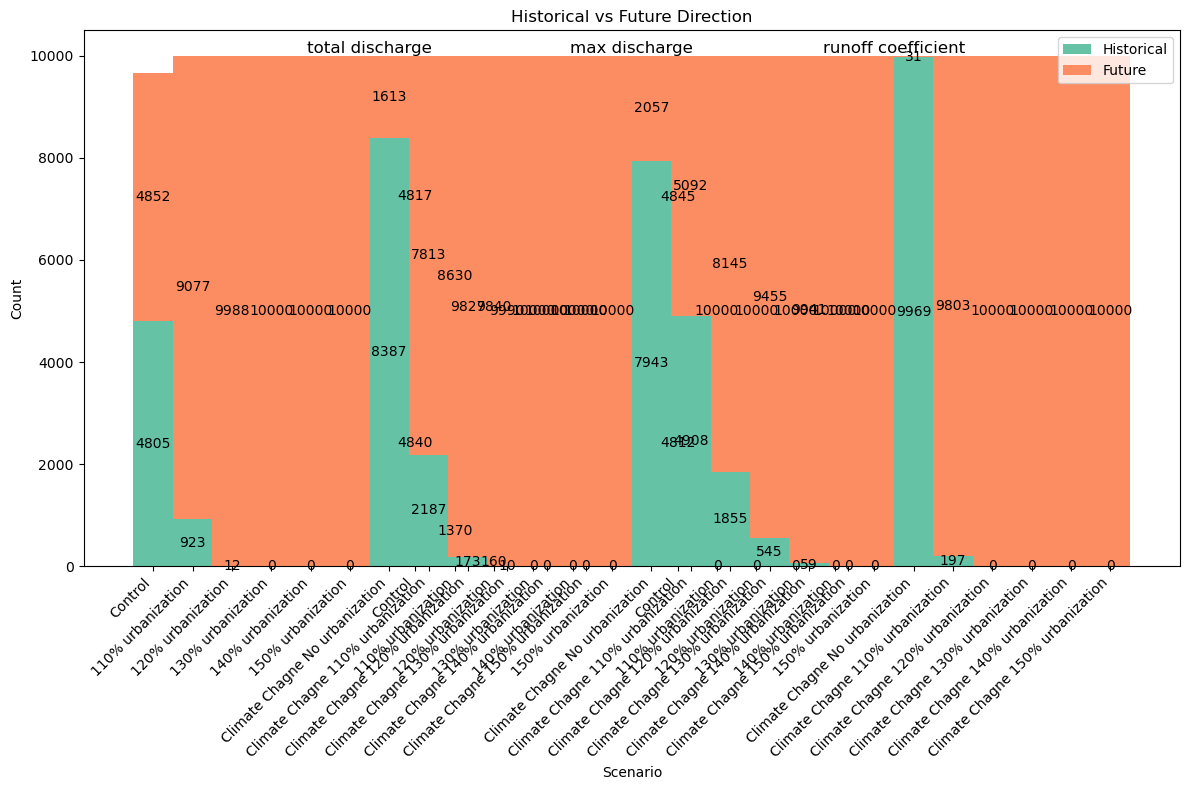

In [3]:
# Colors for historical and future data
historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

# Load data from pickle files
all_data = []
labels = []
for file_name, pickle_file, label_name in rain_shift_classes:
    pickle_file_path = os.path.join(sim_dir, f'all_events_direc_{pickle_file}')
    if os.path.exists(pickle_file_path):
        all_events_direc_df = pd.read_pickle(pickle_file_path)
        all_events_direc_df = all_events_direc_df.head(3)  # Use only the first 3 rows
        all_data.append(all_events_direc_df)
        labels.append(label_name)
    else:
        print(f"Pickle file {pickle_file_path} does not exist.")

# Initialize the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data
width = 0.15
n = len(all_data)
bar_positions = []
bar_labels = []

for i, (all_events_direc_df, label) in enumerate(zip(all_data, labels)):
    pos = [j + (i * width) for j in range(len(all_events_direc_df))]
    bar_positions.extend(pos)
    bar_labels.extend([label] * len(all_events_direc_df))

    # Plot without adding labels for the legend
    bars1 = ax.bar(pos, all_events_direc_df['historical_count'], width=width, color=historical_color)
    bars2 = ax.bar(pos, all_events_direc_df['future_count'], bottom=all_events_direc_df['historical_count'], width=width, color=future_color)

    # Adding annotations for the counts
    for bar, hist_count, fut_count in zip(bars1, all_events_direc_df['historical_count'], all_events_direc_df['future_count']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{hist_count}', ha='center', va='center', fontsize=10, color='black')
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + fut_count / 2, f'{fut_count}', ha='center', va='center', fontsize=10, color='black')

# Add metric labels above the bars
for i, metric in enumerate(all_data[0].index):
    # Calculate the average position for the metric across scenarios
    metric_positions = [
        bar_positions[j * len(all_data[0]) + i] for j in range(n)
    ]
    avg_position = sum(metric_positions) / len(metric_positions)
    
    # Calculate the maximum height for the metric across scenarios
    max_height = max(
        all_data[j]['historical_count'].iloc[i] + all_data[j]['future_count'].iloc[i]
        for j in range(n)
    )
    
    # Place the label above the bars
    ax.text(avg_position, max_height + 1, metric[1].replace("_"," "), ha='center', va='bottom', fontsize=12)

# Customize the plot
plt.title('Historical vs Future Direction')
plt.xlabel('Scenario')
plt.ylabel('Count')

# Set x-ticks positions and labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels, rotation=45, ha='right')

# Create custom legend
hist_patch = plt.Rectangle((0, 0), 1, 1, fc=historical_color, edgecolor='none', label='Historical')
future_patch = plt.Rectangle((0, 0), 1, 1, fc=future_color, edgecolor='none', label='Future')
plt.legend(handles=[hist_patch, future_patch])

plt.tight_layout()

# Save the plot

barplot_path = os.path.join(save_dir, 'all_events_direction_bar_plot_combined.png')
plt.savefig(barplot_path)
plt.show()


## significant

In [4]:
# Colors for historical and future data
historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

# Load data from pickle files
significant_data = []
labels = []  # To store the labels for each DataFrame
for file_name, pickle_file, label_name in rain_shift_classes:
    pickle_file_path = os.path.join(sim_dir, f'significant_events_direc_{pickle_file}')
    if os.path.exists(pickle_file_path):
        significant_events_direc_df = pd.read_pickle(pickle_file_path)
        # Slice the DataFrame to include only the first three rows
        significant_events_direc_df = significant_events_direc_df.head(3)
        significant_data.append(significant_events_direc_df)
        labels.append(label_name)
    else:
        print(f"Pickle file {pickle_file_path} does not exist.")

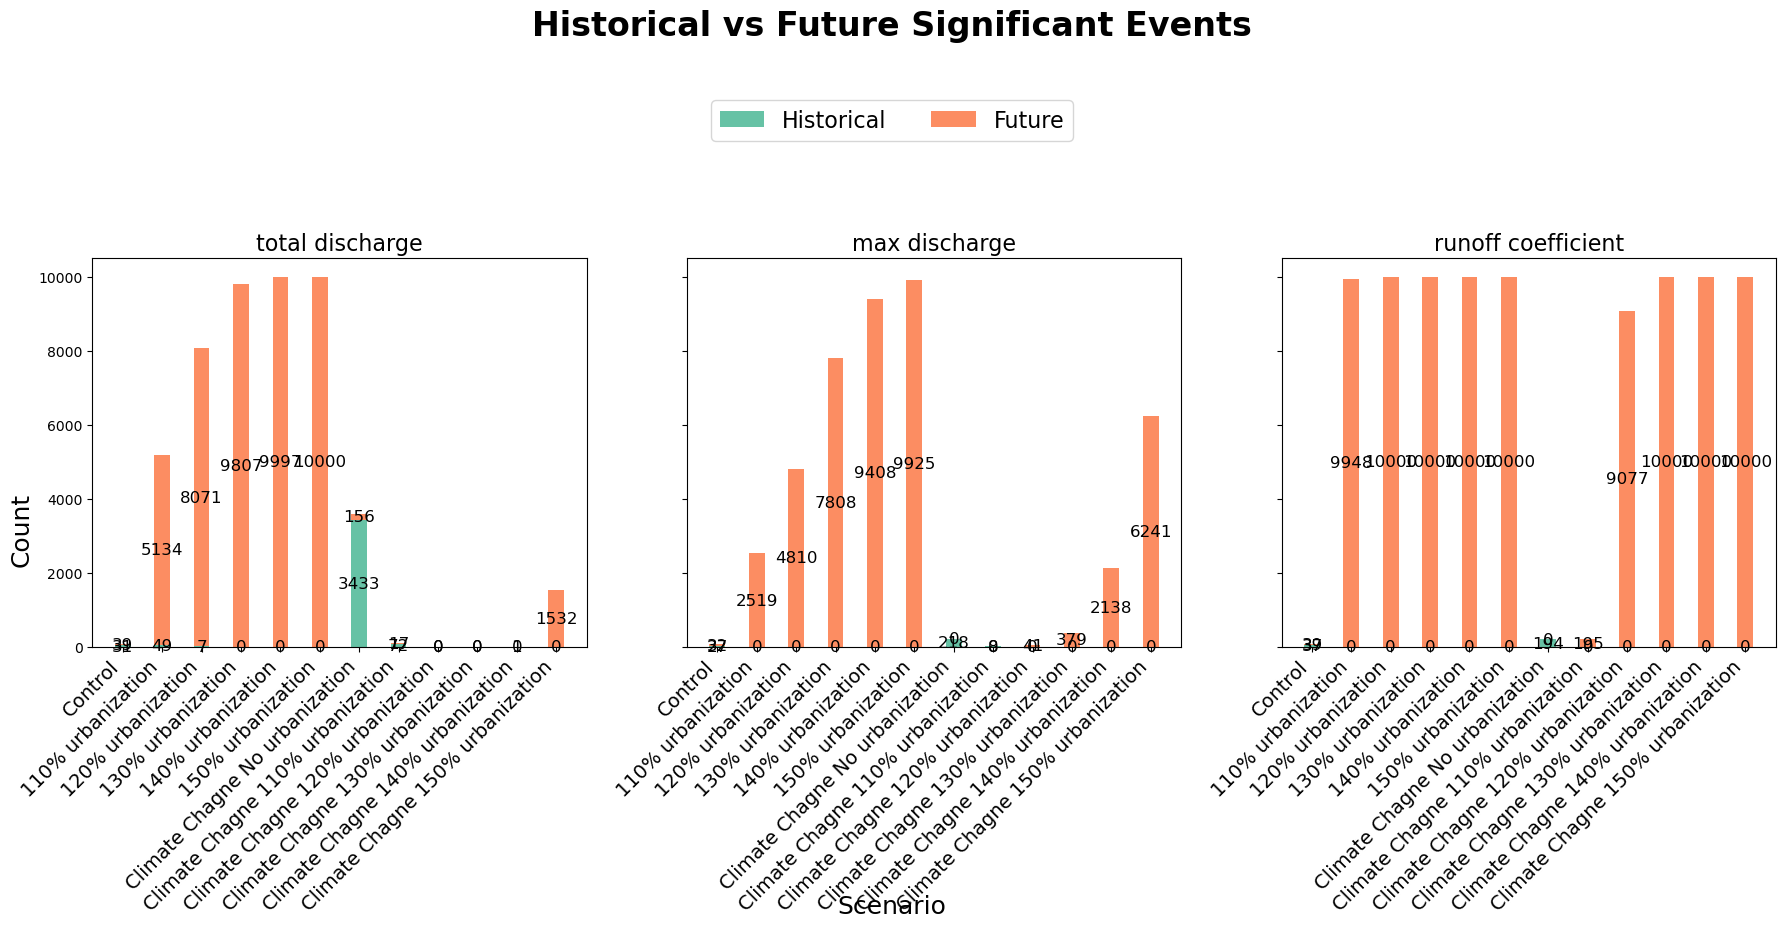

In [5]:

# Initialize the directory to save the subplots
subplots_dir = os.path.join(save_dir, 'subplots_by_metric')
os.makedirs(subplots_dir, exist_ok=True)

# Create subplots for each metric
metrics = significant_data[0].index  # Assuming all metrics are consistent across datasets
fig, axes = plt.subplots(1, len(metrics), figsize=(len(metrics) * 6, 8), sharey=True)

for metric, ax in zip(metrics, axes):
    bar_positions = []
    bar_labels = []
    historical_values = []
    future_values = []
    
    # Collect data for the specific metric across all labels
    for i, (significant_events_direc_df, label) in enumerate(zip(significant_data, labels)):
        historical_values.append(significant_events_direc_df['historical_count'].loc[metric])
        future_values.append(significant_events_direc_df['future_count'].loc[metric])
        bar_positions.append(i)
        bar_labels.append(label)
    
    # Plot the data for the specific metric
    bars1 = ax.bar(bar_positions, historical_values, width=0.4, color=historical_color, label='Historical')
    bars2 = ax.bar(bar_positions, future_values, bottom=historical_values, width=0.4, color=future_color, label='Future')
    
    # Add annotations for counts
    for bar, hist_count, fut_count in zip(bars1, historical_values, future_values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{hist_count}', ha='center', va='center', fontsize=12, color='black')
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + fut_count / 2, f'{fut_count}', ha='center', va='center', fontsize=12, color='black')
    
    # Set x-ticks and labels
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=14)
    
    # Set subplot titles
    ax.set_title(metric[1].replace("_", " "), fontsize=16)

# Set common labels
fig.text(0.5, 0.02, 'Scenario', ha='center', fontsize=18)
fig.text(0.01, 0.5, 'Count', va='center', rotation='vertical', fontsize=18)

# Add a main title and position the legend
fig.suptitle('Historical vs Future Significant Events', fontsize=24, weight='bold', y=1.15)

# Add a shared legend below the title
handles = [
    plt.Rectangle((0, 0), 1, 1, fc=historical_color, edgecolor='none', label='Historical'),
    plt.Rectangle((0, 0), 1, 1, fc=future_color, edgecolor='none', label='Future')
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust rect to fit everything nicely

# Save and show the plot
subplot_path = os.path.join(save_dir, 'significant_events_direction_bar_plot.png')
plt.savefig(subplot_path)
plt.show()


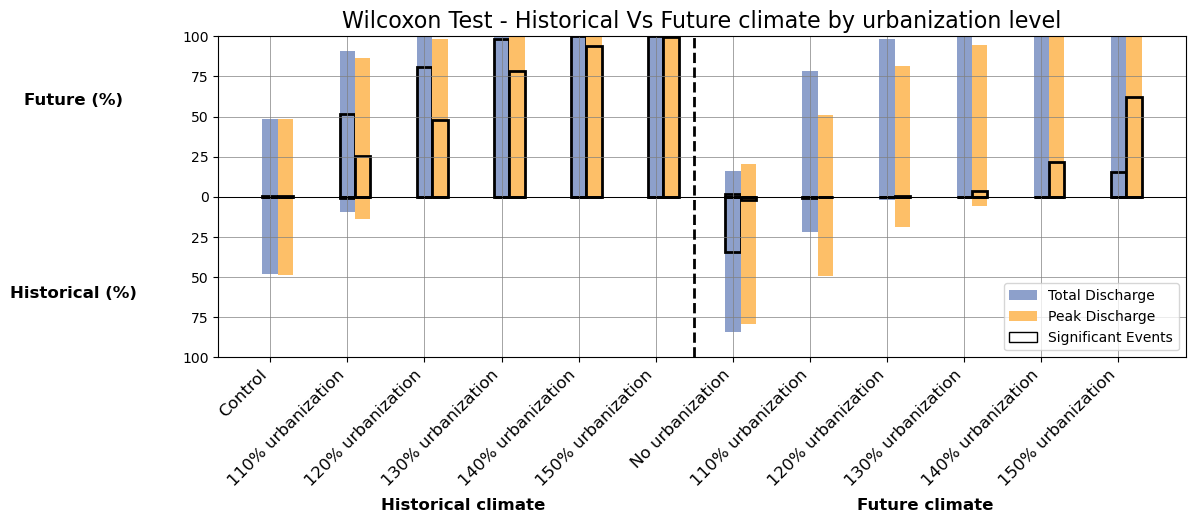

In [6]:
# Define the directory to save the plot
combined_plot_dir = os.path.join(save_dir, 'combined_metric_plot')
os.makedirs(combined_plot_dir, exist_ok=True)

# Define colors: one for total and one for max
color_total = '#8DA0CB'  # Blue
color_max = '#FDBF68'    # Orange

# Prepare data
metrics = significant_data[0][0:2].index  # Assuming all metrics are consistent across datasets
bar_width = 0.2
bar_positions = np.arange(len(labels))

# Find the position for the vertical line
last_climate_index = -1
for idx, label in enumerate(labels):
    if "Climate" not in label:
        last_climate_index = idx

# Calculate the position for the vertical line (midpoint between the last "Climate" label and the next one)
if last_climate_index != -1 and last_climate_index + 1 < len(labels):
    vertical_line_position = last_climate_index + 0.5
else:
    vertical_line_position = None  # No vertical line needed if no "Climate" labels are found

# Create a shortened version of labels
short_labels = []
for label in labels:
    if "Climate" in label:
        short_labels.append(label.split('Climate Chagne ')[-1])  # Extract the part after "Climate Change"
    else:
        short_labels.append(label)

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each metric as a separate group of bars
for i, metric in enumerate(metrics):
    historical_all = [all_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]
    future_all = [all_events_direc_df['future_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]
    historical_sig = [significant_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    future_sig = [significant_events_direc_df['future_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    
    # Determine the label for each metric
    label = metric[1] if isinstance(metric, tuple) else metric
    
    # Determine the color based on the metric index (0: Total, 1: Max)
    bar_color = color_total if i == 0 else color_max
    
    # Plot historical values
    ax.bar(bar_positions + i * bar_width, [-val for val in historical_all],
           width=bar_width, color=bar_color, label=f'{label} (Historical)' if i == 0 else "")
    
    # Plot future values
    ax.bar(bar_positions + i * bar_width, future_all,
           width=bar_width, color=bar_color, label=f'{label} (Future)' if i == 0 else "")

    # Overlay significant historical values
    ax.bar(bar_positions + i * bar_width, [-val for val in historical_sig],
           width=bar_width, edgecolor='black', linewidth=2, fill=False)
    
    # Overlay significant future values
    ax.bar(bar_positions + i * bar_width, future_sig,
           width=bar_width, edgecolor='black', linewidth=2, fill=False)

# Add the vertical line if applicable
if vertical_line_position is not None:
    ax.axvline(x=vertical_line_position, color='black', linestyle='--', linewidth=2, label='Climate Change Boundary')

# Add horizontal line at X=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.75)

# Adjust y-axis ticks to show percentages
ax.set_ylim(-100, 100)
y_ticks = ax.get_yticks()
ax.set_yticks(y_ticks)
ax.set_yticklabels([abs(int(tick)) for tick in y_ticks])

# Add labels for "Future" and "Historical" at a fixed height
ax.text(-0.15, 80 / ax.get_ylim()[1], 'Future (%)', transform=ax.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax.text(-0.15, 20 / ax.get_ylim()[1], 'Historical (%)', transform=ax.transAxes, fontsize=12, weight='bold', ha='center', va='center')

# Add gridlines for clarity
ax.grid(linewidth=0.5, color='gray')

# Set x-ticks and labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)

# Add split labels for the x-axis
if vertical_line_position is not None:
    ax.text(vertical_line_position - 3, -195, 'Historical climate', fontsize=12, weight='bold', ha='center')
    ax.text(vertical_line_position + 3, -195, 'Future climate', fontsize=12, weight='bold', ha='center')

# Set axis labels and title

ax.set_title('Wilcoxon Test - Historical Vs Future climate by urbanization level', fontsize=16)


# Simplify the legend to include two types
handles = [
    Patch(facecolor=color_total, label='Total Discharge'),
    Patch(facecolor=color_max, label='Peak Discharge'),
    Patch(facecolor='none', edgecolor='black', label='Significant Events')
]

# Update the legend
ax.legend(handles=handles, loc='lower right', fontsize=10)


# Adjust layout and save the plot
plt.tight_layout()
combined_plot_path = os.path.join(combined_plot_dir, 'combined_metrics_percentage_plot.png')
plt.savefig(combined_plot_path, dpi=300)  # Save with high DPI for clarity
plt.show()

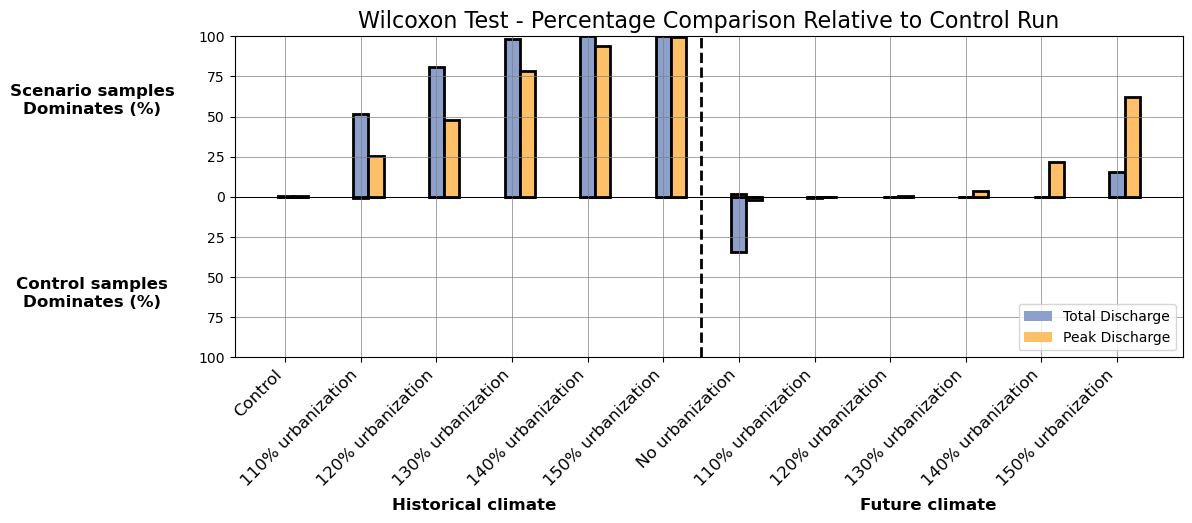

In [7]:
# Prepare data
metrics = significant_data[0][0:2].index  # Assuming all metrics are consistent across datasets
bar_width = 0.2
bar_positions = np.arange(len(labels))

# Find the position for the vertical line
last_climate_index = -1
for idx, label in enumerate(labels):
    if "Climate" not in label:
        last_climate_index = idx

# Calculate the position for the vertical line (midpoint between the last "Climate" label and the next one)
if last_climate_index != -1 and last_climate_index + 1 < len(labels):
    vertical_line_position = last_climate_index + 0.5
else:
    vertical_line_position = None  # No vertical line needed if no "Climate" labels are found

# Create a shortened version of labels
short_labels = []
for label in labels:
    if "Climate" in label:
        short_labels.append(label.split('Climate Chagne ')[-1])  # Extract the part after "Climate Change"
    else:
        short_labels.append(label)

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each metric as a separate group of bars
for i, metric in enumerate(metrics):
    # Use only significant data
    historical_sig = [significant_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    future_sig = [significant_events_direc_df['future_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    
    # Determine the label for each metric
    label = metric[1] if isinstance(metric, tuple) else metric
    
    # Determine the color based on the metric index (0: Total, 1: Max)
    bar_color = color_total if i == 0 else color_max
    
    # Plot significant historical values
    ax.bar(bar_positions + i * bar_width, [-val for val in historical_sig],
           width=bar_width, color=bar_color, edgecolor='black', linewidth=2, label=f'{label} (Historical)' if i == 0 else "")
    
    # Plot significant future values
    ax.bar(bar_positions + i * bar_width, future_sig,
           width=bar_width, color=bar_color, edgecolor='black', linewidth=2, label=f'{label} (Future)' if i == 0 else "")

# Add the vertical line if applicable
if vertical_line_position is not None:
    ax.axvline(x=vertical_line_position, color='black', linestyle='--', linewidth=2, label='Climate Change Boundary')

# Add horizontal line at X=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.75)

# Adjust y-axis ticks to show percentages
ax.set_ylim(-100, 100)
y_ticks = ax.get_yticks()
ax.set_yticks(y_ticks)
ax.set_yticklabels([abs(int(tick)) for tick in y_ticks])

# Add labels for "Future" and "Historical" at a fixed height
ax.text(-0.15, 80 / ax.get_ylim()[1], 'Scenario samples\nDominates (%)', transform=ax.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax.text(-0.15, 20 / ax.get_ylim()[1], 'Control samples\nDominates (%)', transform=ax.transAxes, fontsize=12, weight='bold', ha='center', va='center')

# Add gridlines for clarity
ax.grid(linewidth=0.5, color='gray')

# Set x-ticks and labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)

# Add split labels for the x-axis
if vertical_line_position is not None:
    ax.text(vertical_line_position - 3, -195, 'Historical climate', fontsize=12, weight='bold', ha='center')
    ax.text(vertical_line_position + 3, -195, 'Future climate', fontsize=12, weight='bold', ha='center')

# Set axis labels and title
ax.set_title('Wilcoxon Test - Percentage Comparison Relative to Control Run', fontsize=16)

# Simplify the legend to include two types
handles = [
    Patch(facecolor=color_total, label='Total Discharge'),
    Patch(facecolor=color_max, label='Peak Discharge'),
#     Patch(facecolor='none', edgecolor='black', label='Significant Events')
]

# Update the legend
ax.legend(handles=handles, loc='lower right', fontsize=10)

# Adjust layout and save the plot
plt.tight_layout()
combined_plot_path = os.path.join(combined_plot_dir, 'combined_metrics_percentage_plot_significant.png')
plt.savefig(combined_plot_path, dpi=300)  # Save with high DPI for clarity
plt.show()


In [8]:
historical_all = [all_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]
future_all = [all_events_direc_df['future_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]

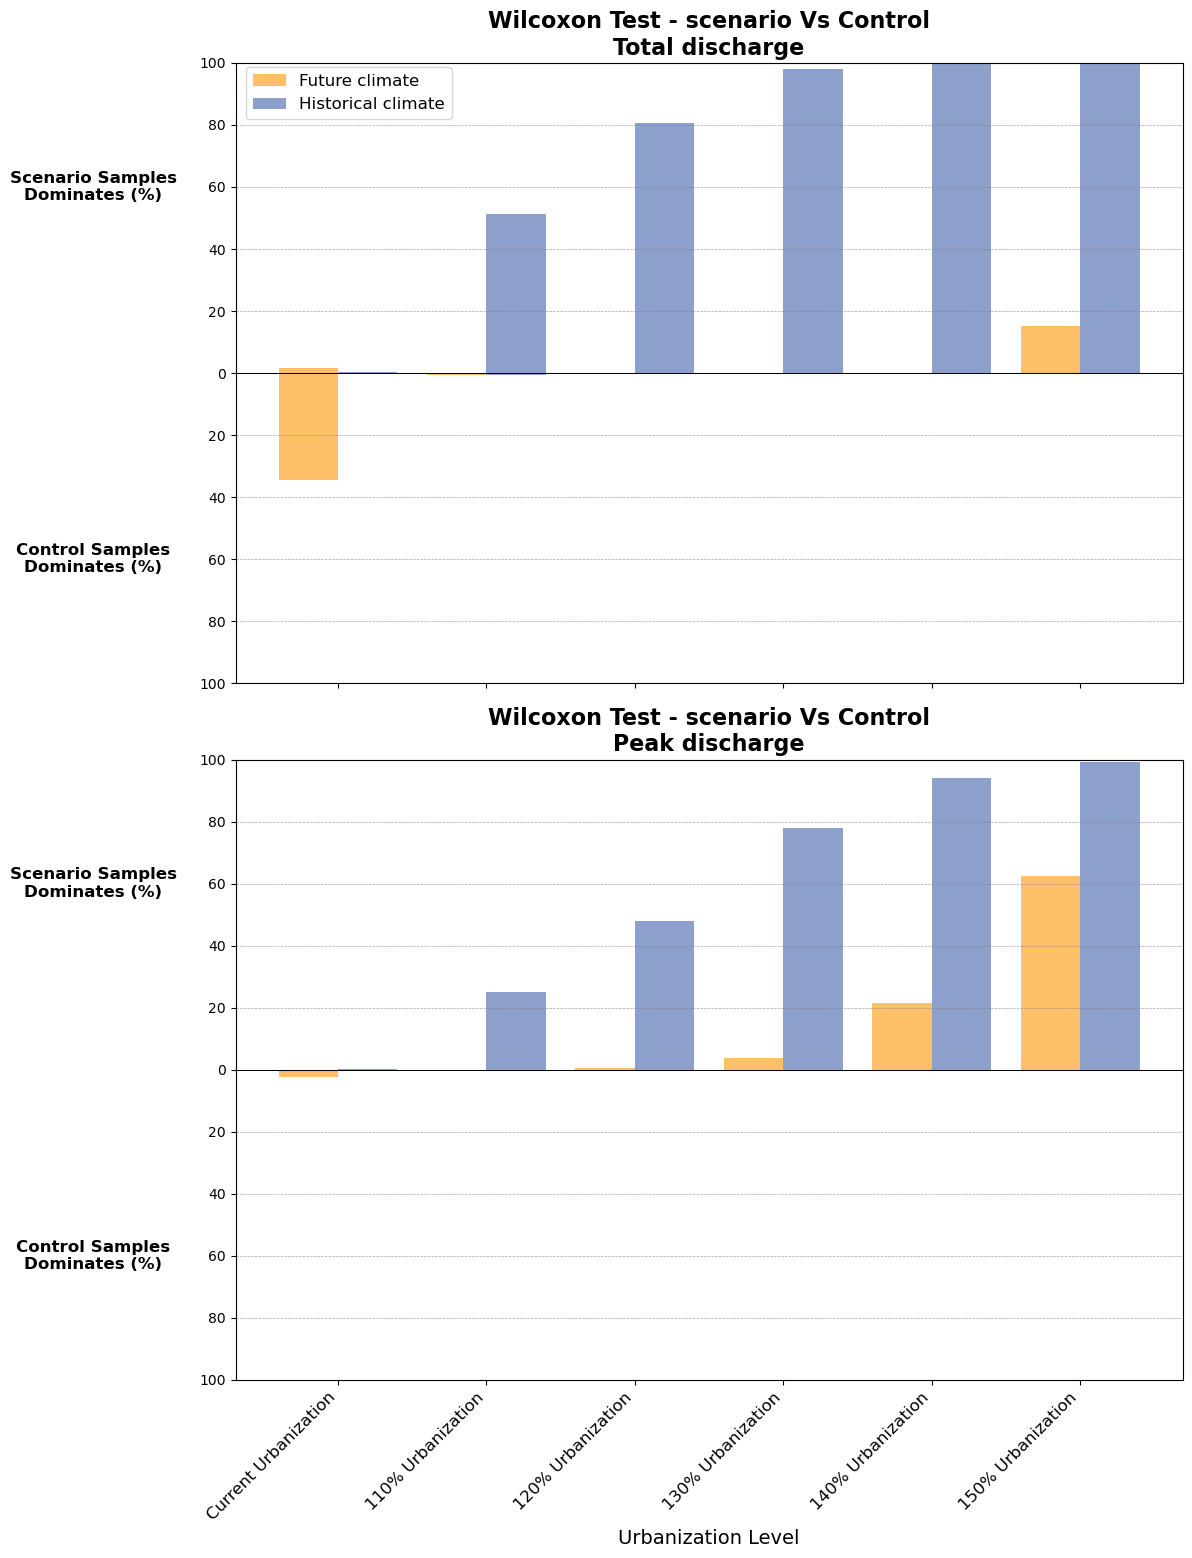

In [9]:
# Filter the relevant data for the 6 groups based on urbanization level
grouped_data = [
    ('Current Urbanization', significant_data[0], significant_data[6]),
    ('110% Urbanization', significant_data[1], significant_data[7]),
    ('120% Urbanization', significant_data[2], significant_data[8]),
    ('130% Urbanization', significant_data[3], significant_data[9]),
    ('140% Urbanization', significant_data[4], significant_data[10]),
    ('150% Urbanization', significant_data[5], significant_data[11]),
]

# Extract data for total discharge
historical_future_discharge = [
    group[1]['future_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
future_discharge = [
    group[2]['future_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
historical_historical_discharge = [
    -group[1]['historical_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
historical_discharge = [
    -group[2]['historical_count'].iloc[0] / 10000 * 100 for group in grouped_data
]

# Extract data for peak discharge
historical_future_peaks = [
    group[1]['future_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
future_peaks = [
    group[2]['future_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
historical_historical_peaks = [
    -group[1]['historical_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
historical_peaks = [
    -group[2]['historical_count'].iloc[1] / 10000 * 100 for group in grouped_data
]

# Define the bar positions and width
bar_width = 0.4
x_positions = np.arange(len(grouped_data))

# Create the figure and axes
fig, (ax_total, ax_peak) = plt.subplots(2, 1, figsize=(12, 16), sharex=True)

# Set Y-axis limits and ticks
shared_y_min = -100
shared_y_max = 100
y_ticks = np.arange(shared_y_min, shared_y_max + 20, 20)

# Plot Total Discharge
for idx in range(len(grouped_data)):
    ax_total.bar(
        x_positions[idx] - bar_width / 2, future_discharge[idx],
        width=bar_width, color='#FDBF68', label='Future' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] + bar_width / 2, historical_future_discharge[idx],
        width=bar_width, color='#8DA0CB', label='Future Historical' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] - bar_width / 2, historical_discharge[idx],
        width=bar_width, color='#FDBF68', label='Historical Future' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] + bar_width / 2, historical_historical_discharge[idx],
        width=bar_width, color='#8DA0CB', label='Historical' if idx == 0 else ""
    )

ax_total.set_ylim(shared_y_min, shared_y_max)
ax_total.set_yticks(y_ticks)
ax_total.set_yticklabels([f"{abs(tick)}" for tick in y_ticks])
ax_total.grid(which='both', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax_total.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_total.set_title('Wilcoxon Test - scenario Vs Control\nTotal discharge', fontsize=16, weight='bold')


# Add text next to the Y-axis for Total Discharge
ax_total.text(-0.15, 0.8, 'Scenario Samples\nDominates (%)', transform=ax_total.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax_total.text(-0.15, 0.2, 'Control Samples\nDominates (%)', transform=ax_total.transAxes, fontsize=12, weight='bold', ha='center', va='center')

# Plot Peak Discharge
for idx in range(len(grouped_data)):
    ax_peak.bar(
        x_positions[idx] - bar_width / 2, future_peaks[idx],
        width=bar_width, color='#FDBF68', label='Future' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] + bar_width / 2, historical_future_peaks[idx],
        width=bar_width, color='#8DA0CB', label='Future Historical' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] - bar_width / 2, historical_peaks[idx],
        width=bar_width, color='#FDBF68', label='Historical Future' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] + bar_width / 2, historical_historical_peaks[idx],
        width=bar_width, color='#8DA0CB', label='Historical' if idx == 0 else ""
    )

ax_peak.set_ylim(shared_y_min, shared_y_max)
ax_peak.set_yticks(y_ticks)
ax_peak.set_yticklabels([f"{abs(tick)}" for tick in y_ticks])
ax_peak.grid(which='both', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax_peak.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_peak.set_title('Wilcoxon Test - scenario Vs Control\nPeak discharge', fontsize=16, weight='bold')
ax_peak.set_xlabel('Urbanization Level', fontsize=14)

# Add text next to the Y-axis for Peak Discharge
ax_peak.text(-0.15, 0.8, 'Scenario Samples\nDominates (%)', transform=ax_peak.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax_peak.text(-0.15, 0.2, 'Control Samples\nDominates (%)', transform=ax_peak.transAxes, fontsize=12, weight='bold', ha='center', va='center')

# Shared X-axis labels
ax_peak.set_xticks(x_positions)
ax_peak.set_xticklabels([group[0] for group in grouped_data], rotation=45, ha='right', fontsize=12)

# Add legend
handles = [
    Patch(facecolor='#FDBF68', label='Future climate'),
    Patch(facecolor='#8DA0CB', label='Historical climate'),
]
fig.legend(handles=handles, fontsize=12, loc='upper left', ncol=1, bbox_to_anchor=(0.2, 0.94))

# Save and show the plot
plt.tight_layout(rect=[0, 0, 1, 0.98])
combined_discharge_path = os.path.join(save_dir, 'combined_discharge_percentage_grouped.png')
plt.savefig(combined_discharge_path, dpi=300)
plt.show()


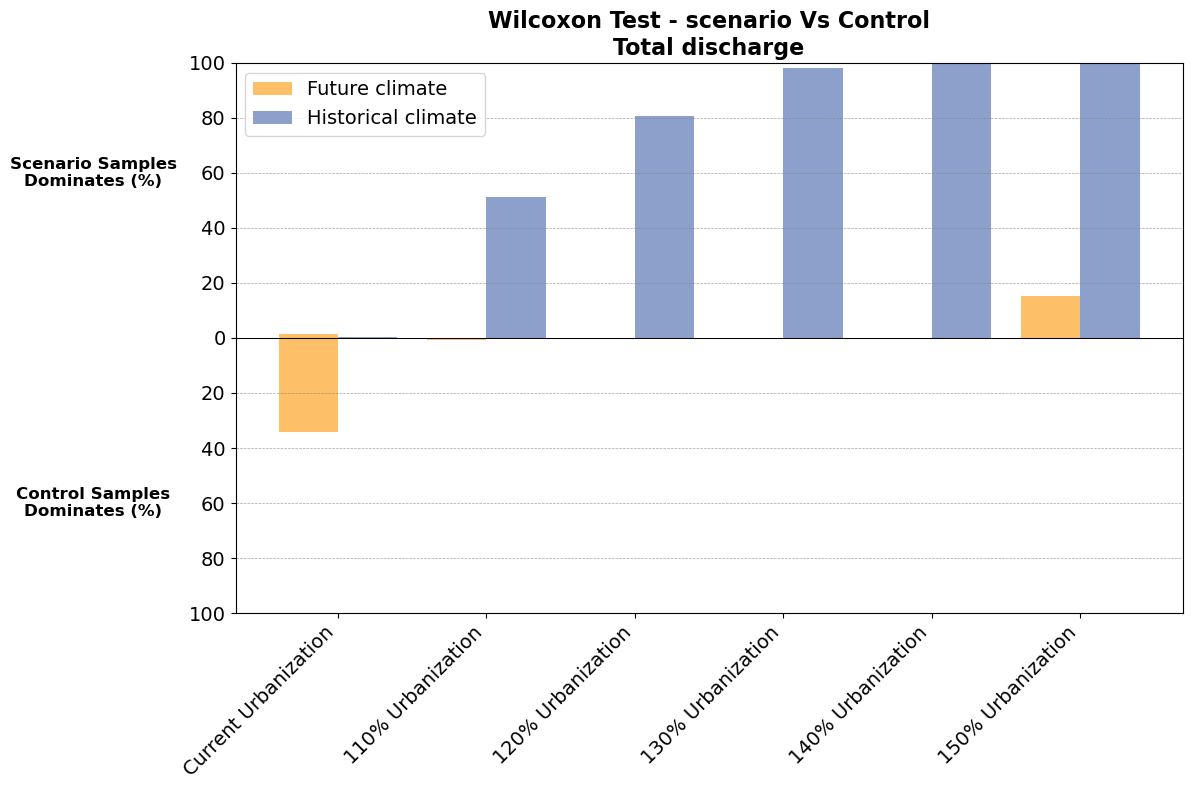

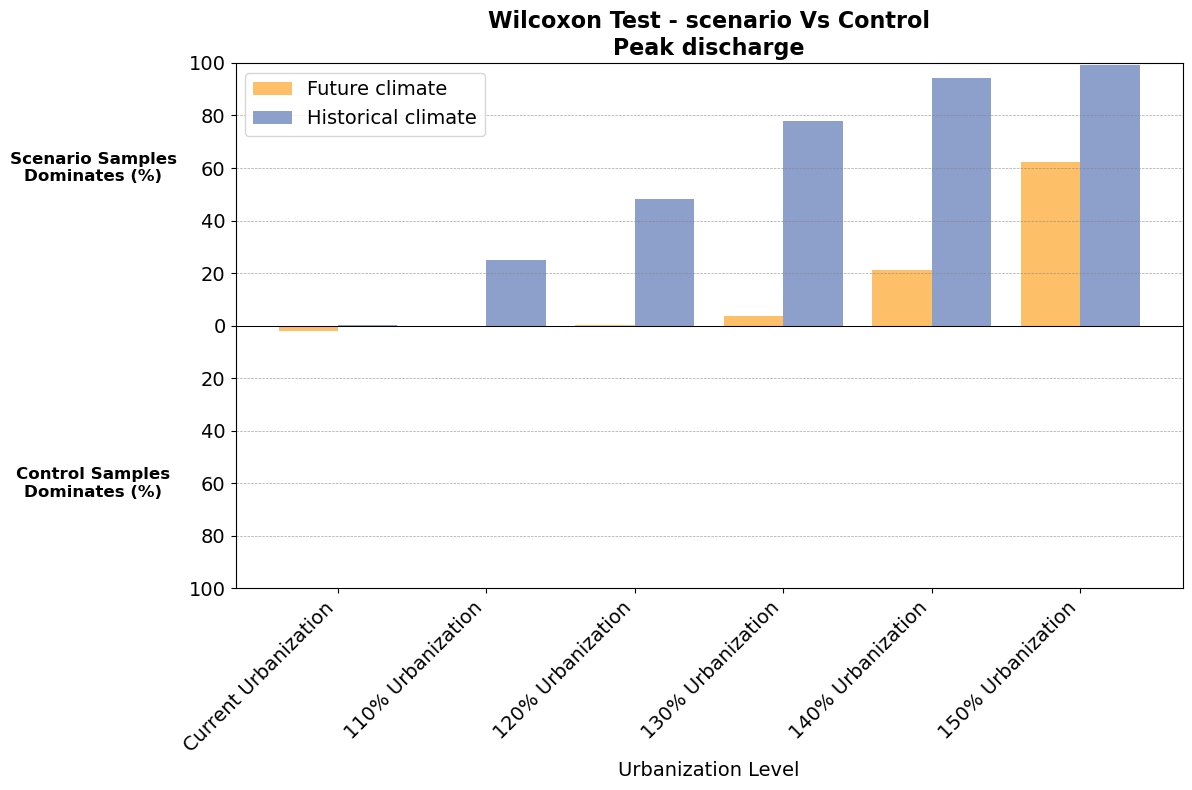

In [10]:
# Filter the relevant data for the 6 groups based on urbanization level
grouped_data = [
    ('Current Urbanization', significant_data[0], significant_data[6]),
    ('110% Urbanization', significant_data[1], significant_data[7]),
    ('120% Urbanization', significant_data[2], significant_data[8]),
    ('130% Urbanization', significant_data[3], significant_data[9]),
    ('140% Urbanization', significant_data[4], significant_data[10]),
    ('150% Urbanization', significant_data[5], significant_data[11]),
]

# Extract data for total discharge
historical_future_discharge = [
    group[1]['future_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
future_discharge = [
    group[2]['future_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
historical_historical_discharge = [
    -group[1]['historical_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
historical_discharge = [
    -group[2]['historical_count'].iloc[0] / 10000 * 100 for group in grouped_data
]

# Extract data for peak discharge
historical_future_peaks = [
    group[1]['future_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
future_peaks = [
    group[2]['future_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
historical_historical_peaks = [
    -group[1]['historical_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
historical_peaks = [
    -group[2]['historical_count'].iloc[1] / 10000 * 100 for group in grouped_data
]

# Define the bar positions and width
bar_width = 0.4
x_positions = np.arange(len(grouped_data))

# Shared Y-axis limits and ticks
shared_y_min = -100
shared_y_max = 100
y_ticks = np.arange(shared_y_min, shared_y_max + 20, 20)

# Plot Total Discharge
fig_total, ax_total = plt.subplots(figsize=(12, 8))
for idx in range(len(grouped_data)):
    ax_total.bar(
        x_positions[idx] - bar_width / 2, future_discharge[idx],
        width=bar_width, color='#FDBF68', label='Future' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] + bar_width / 2, historical_future_discharge[idx],
        width=bar_width, color='#8DA0CB', label='Future Historical' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] - bar_width / 2, historical_discharge[idx],
        width=bar_width, color='#FDBF68', label='Historical Future' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] + bar_width / 2, historical_historical_discharge[idx],
        width=bar_width, color='#8DA0CB', label='Historical' if idx == 0 else ""
    )

ax_total.set_ylim(shared_y_min, shared_y_max)
ax_total.set_yticks(y_ticks)
ax_total.set_yticklabels([f"{abs(tick)}" for tick in y_ticks], fontsize=14)
ax_total.grid(which='both', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax_total.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_total.set_title('Wilcoxon Test - scenario Vs Control\nTotal discharge', fontsize=16, weight='bold')

ax_total.set_xticks(x_positions)
ax_total.set_xticklabels([group[0] for group in grouped_data], rotation=45, ha='right', fontsize=14)

# Add text next to the Y-axis for Total Discharge
ax_total.text(-0.15, 0.8, 'Scenario Samples\nDominates (%)', transform=ax_total.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax_total.text(-0.15, 0.2, 'Control Samples\nDominates (%)', transform=ax_total.transAxes, fontsize=12, weight='bold', ha='center', va='center')

handles = [
    Patch(facecolor='#FDBF68', label='Future climate'),
    Patch(facecolor='#8DA0CB', label='Historical climate'),
]
ax_total.legend(handles=handles, fontsize=14, loc='upper left')

# Save and show the Total Discharge plot
total_discharge_path = os.path.join(save_dir, 'total_discharge_percentage_grouped.png')
plt.tight_layout()
plt.savefig(total_discharge_path, dpi=300)
plt.show()

# Plot Peak Discharge
fig_peak, ax_peak = plt.subplots(figsize=(12, 8))
for idx in range(len(grouped_data)):
    ax_peak.bar(
        x_positions[idx] - bar_width / 2, future_peaks[idx],
        width=bar_width, color='#FDBF68', label='Future' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] + bar_width / 2, historical_future_peaks[idx],
        width=bar_width, color='#8DA0CB', label='Future Historical' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] - bar_width / 2, historical_peaks[idx],
        width=bar_width, color='#FDBF68', label='Historical Future' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] + bar_width / 2, historical_historical_peaks[idx],
        width=bar_width, color='#8DA0CB', label='Historical' if idx == 0 else ""
    )

ax_peak.set_ylim(shared_y_min, shared_y_max)
ax_peak.set_yticks(y_ticks)
ax_peak.set_yticklabels([f"{abs(tick)}" for tick in y_ticks], fontsize=14)
ax_peak.grid(which='both', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax_peak.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_peak.set_title('Wilcoxon Test - scenario Vs Control\nPeak discharge', fontsize=16, weight='bold')
ax_peak.set_xlabel('Urbanization Level', fontsize=14)
ax_peak.set_xticks(x_positions)
ax_peak.set_xticklabels([group[0] for group in grouped_data], rotation=45, ha='right', fontsize=14)

# Add text next to the Y-axis for Peak Discharge
ax_peak.text(-0.15, 0.8, 'Scenario Samples\nDominates (%)', transform=ax_peak.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax_peak.text(-0.15, 0.2, 'Control Samples\nDominates (%)', transform=ax_peak.transAxes, fontsize=12, weight='bold', ha='center', va='center')

handles = [
    Patch(facecolor='#FDBF68', label='Future climate'),
    Patch(facecolor='#8DA0CB', label='Historical climate'),
]
ax_peak.legend(handles=handles, fontsize=14, loc='upper left')

# Save and show the Peak Discharge plot
peak_discharge_path = os.path.join(save_dir, 'peak_discharge_percentage_grouped.png')
plt.tight_layout()
plt.savefig(peak_discharge_path, dpi=300)
plt.show()


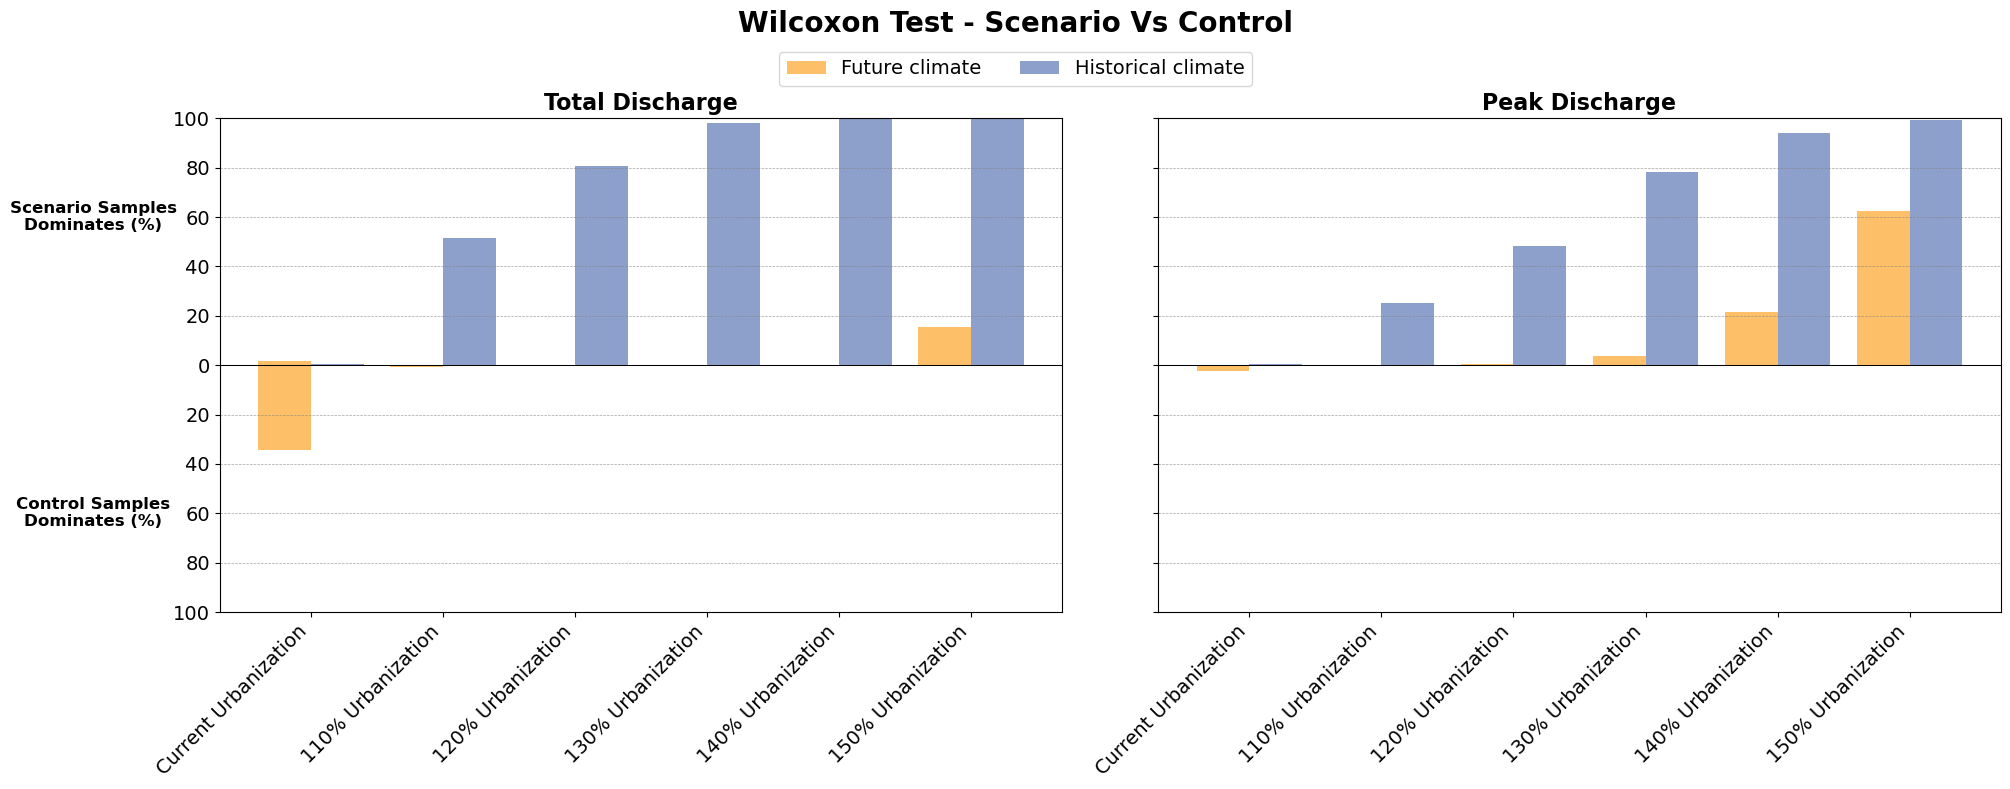

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Filter the relevant data for the 6 groups based on urbanization level
grouped_data = [
    ('Current Urbanization', significant_data[0], significant_data[6]),
    ('110% Urbanization', significant_data[1], significant_data[7]),
    ('120% Urbanization', significant_data[2], significant_data[8]),
    ('130% Urbanization', significant_data[3], significant_data[9]),
    ('140% Urbanization', significant_data[4], significant_data[10]),
    ('150% Urbanization', significant_data[5], significant_data[11]),
]

# Extract data for total discharge
historical_future_discharge = [
    group[1]['future_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
future_discharge = [
    group[2]['future_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
historical_historical_discharge = [
    -group[1]['historical_count'].iloc[0] / 10000 * 100 for group in grouped_data
]
historical_discharge = [
    -group[2]['historical_count'].iloc[0] / 10000 * 100 for group in grouped_data
]

# Extract data for peak discharge
historical_future_peaks = [
    group[1]['future_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
future_peaks = [
    group[2]['future_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
historical_historical_peaks = [
    -group[1]['historical_count'].iloc[1] / 10000 * 100 for group in grouped_data
]
historical_peaks = [
    -group[2]['historical_count'].iloc[1] / 10000 * 100 for group in grouped_data
]

# Define the bar positions and width
bar_width = 0.4
x_positions = np.arange(len(grouped_data))

# Shared Y-axis limits and ticks
shared_y_min = -100
shared_y_max = 100
y_ticks = np.arange(shared_y_min, shared_y_max + 20, 20)

# Create the figure and subplots
fig, (ax_total, ax_peak) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
fig.suptitle('Wilcoxon Test - Scenario Vs Control', fontsize=20, weight='bold')

# Plot Total Discharge
for idx in range(len(grouped_data)):
    ax_total.bar(
        x_positions[idx] - bar_width / 2, future_discharge[idx],
        width=bar_width, color='#FDBF68', label='Future' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] + bar_width / 2, historical_future_discharge[idx],
        width=bar_width, color='#8DA0CB', label='Future Historical' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] - bar_width / 2, historical_discharge[idx],
        width=bar_width, color='#FDBF68', label='Historical Future' if idx == 0 else ""
    )
    ax_total.bar(
        x_positions[idx] + bar_width / 2, historical_historical_discharge[idx],
        width=bar_width, color='#8DA0CB', label='Historical' if idx == 0 else ""
    )

ax_total.set_ylim(shared_y_min, shared_y_max)
ax_total.set_yticks(y_ticks)
ax_total.set_yticklabels([f"{abs(tick)}" for tick in y_ticks], fontsize=14)
ax_total.grid(which='both', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax_total.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_total.set_title('Total Discharge', fontsize=16, weight='bold')

ax_total.set_xticks(x_positions)
ax_total.set_xticklabels([group[0] for group in grouped_data], rotation=45, ha='right', fontsize=14)

# Add text next to the Y-axis for Total Discharge
ax_total.text(-0.15, 0.8, 'Scenario Samples\nDominates (%)', transform=ax_total.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax_total.text(-0.15, 0.2, 'Control Samples\nDominates (%)', transform=ax_total.transAxes, fontsize=12, weight='bold', ha='center', va='center')

# Plot Peak Discharge
for idx in range(len(grouped_data)):
    ax_peak.bar(
        x_positions[idx] - bar_width / 2, future_peaks[idx],
        width=bar_width, color='#FDBF68', label='Future' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] + bar_width / 2, historical_future_peaks[idx],
        width=bar_width, color='#8DA0CB', label='Future Historical' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] - bar_width / 2, historical_peaks[idx],
        width=bar_width, color='#FDBF68', label='Historical Future' if idx == 0 else ""
    )
    ax_peak.bar(
        x_positions[idx] + bar_width / 2, historical_historical_peaks[idx],
        width=bar_width, color='#8DA0CB', label='Historical' if idx == 0 else ""
    )

ax_peak.set_ylim(shared_y_min, shared_y_max)
ax_peak.set_yticks(y_ticks)
ax_peak.set_yticklabels([f"{abs(tick)}" for tick in y_ticks], fontsize=14)
ax_peak.grid(which='both', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax_peak.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_peak.set_title('Peak Discharge', fontsize=16, weight='bold')
ax_peak.set_xticks(x_positions)
ax_peak.set_xticklabels([group[0] for group in grouped_data], rotation=45, ha='right', fontsize=14)

# # Add text next to the Y-axis for Peak Discharge
# ax_peak.text(-0.15, 0.8, 'Scenario Samples\nDominates (%)', transform=ax_peak.transAxes, fontsize=12, weight='bold', ha='center', va='center')
# ax_peak.text(-0.15, 0.2, 'Control Samples\nDominates (%)', transform=ax_peak.transAxes, fontsize=12, weight='bold', ha='center', va='center')

# Add legend
handles = [
    Patch(facecolor='#FDBF68', label='Future climate'),
    Patch(facecolor='#8DA0CB', label='Historical climate'),
]
fig.legend(handles=handles, fontsize=14, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.94))

# Save and show the combined plot
combined_discharge_path = os.path.join(save_dir, 'combined_discharge_percentage_grouped_side_by_side.png')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(combined_discharge_path, dpi=300)
plt.show()


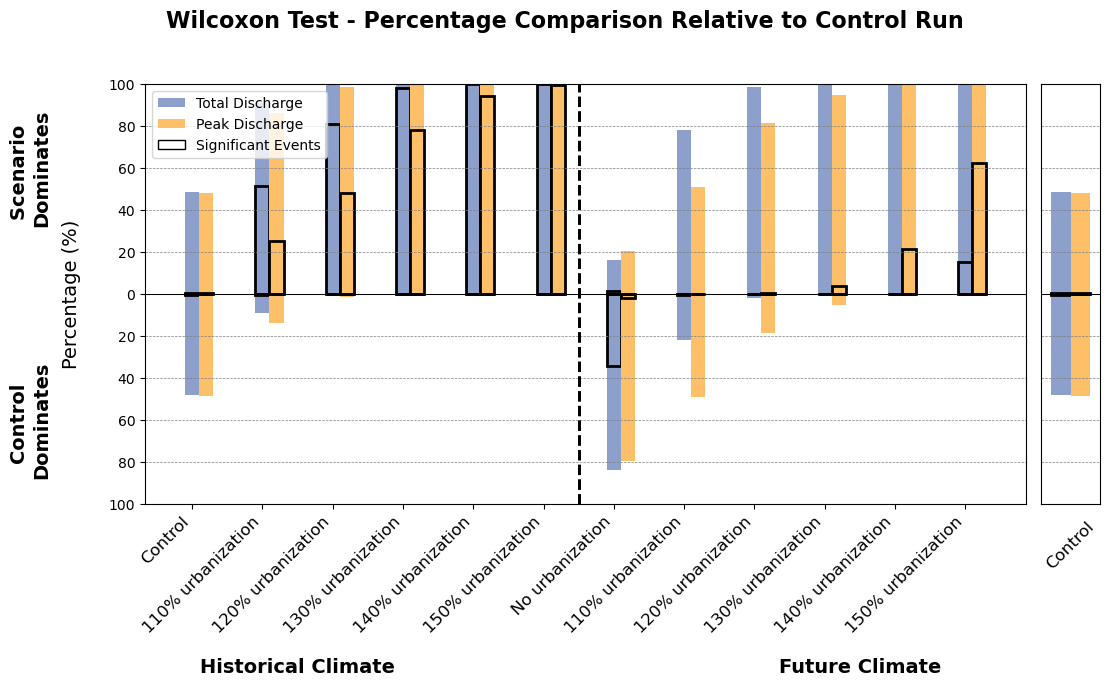

In [12]:
# Define the directory to save the plot
combined_plot_dir = os.path.join(save_dir, 'combined_metric_plot')
os.makedirs(combined_plot_dir, exist_ok=True)

# Define colors: one for total and one for max
color_total = '#8DA0CB'  # Blue
color_max = '#FDBF68'    # Orange

# Prepare data
metrics = significant_data[0][0:2].index  # Assuming all metrics are consistent across datasets
bar_width = 0.2
bar_positions = np.arange(len(labels))

# Find the position for the vertical line
last_climate_index = -1
for idx, label in enumerate(labels):
    if "Climate" not in label:
        last_climate_index = idx

# Calculate the position for the vertical line (midpoint between the last "Climate" label and the next one)
if last_climate_index != -1 and last_climate_index + 1 < len(labels):
    vertical_line_position = last_climate_index + 0.5
else:
    vertical_line_position = None  # No vertical line needed if no "Climate" labels are found

# Create a shortened version of labels without "Climate Change"
short_labels = [label.replace("Climate Chagne ", "").replace("Climate Change ", "").strip() for label in labels]

# Define the index for control scenario
control_index = labels.index("Control") if "Control" in labels else None

# Create the figure with subplots
fig, (ax_main, ax_sub) = plt.subplots(
    1, 2, figsize=(11, 8), gridspec_kw={'width_ratios': [15, 1]}
)

# Set shared y-axis limits and ticks
shared_y_min = -100  # or calculate dynamically based on data
shared_y_max = 100   # or calculate dynamically based on data
y_ticks = np.arange(shared_y_min, shared_y_max + 1, 20)  # Define tick intervals

# Apply to both axes
ax_main.set_ylim(shared_y_min, shared_y_max)
ax_sub.set_ylim(shared_y_min, shared_y_max)
ax_main.set_yticks(y_ticks)
ax_sub.set_yticks(y_ticks)

# Update y-ticks to display absolute values
y_tick_labels = [f"{abs(tick)}" for tick in y_ticks]
ax_main.set_yticklabels(y_tick_labels)
ax_sub.set_yticklabels(y_tick_labels)

# Add gridlines to both axes
ax_main.grid(which='both', axis='y', linewidth=0.5, color='gray', linestyle='--')
ax_sub.grid(which='both', axis='y', linewidth=0.5, color='gray', linestyle='--')

# Remove ticks and labels for x and y axes in the right subplot
ax_sub.tick_params(axis='y', which='both', left=False, labelleft=False)
ax_sub.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Main Plot: Plot each metric as a separate group of bars
for i, metric in enumerate(metrics):
    historical_all = [all_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]
    future_all = [all_events_direc_df['future_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]
    historical_sig = [significant_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    future_sig = [significant_events_direc_df['future_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    
    # Determine the label for each metric
    label = metric[1] if isinstance(metric, tuple) else metric
    
    # Determine the color based on the metric index (0: Total, 1: Max)
    bar_color = color_total if i == 0 else color_max
    
    # Main plot bars
    for idx, (hist_all, fut_all, hist_sig, fut_sig) in enumerate(zip(historical_all, future_all, historical_sig, future_sig)):
        ax_main.bar(bar_positions[idx] + i * bar_width, -hist_all,
                    width=bar_width, color=bar_color, label=f'{label} (Historical)' if i == 0 else "")
        ax_main.bar(bar_positions[idx] + i * bar_width, fut_all,
                    width=bar_width, color=bar_color, label=f'{label} (Future)' if i == 0 else "")
        ax_main.bar(bar_positions[idx] + i * bar_width, -hist_sig,
                    width=bar_width, edgecolor='black', linewidth=2, fill=False)
        ax_main.bar(bar_positions[idx] + i * bar_width, fut_sig,
                    width=bar_width, edgecolor='black', linewidth=2, fill=False)

    # Subplot bars for the control scenario only
    if control_index is not None:
        control_positions = np.arange(len(metrics)) * bar_width  # Define positions for control bars
        ax_sub.set_xlim(-bar_width, len(metrics) * bar_width)  # Set x-axis limits for control subplot
        ax_sub.bar(control_positions[i], -historical_all[control_index], 
                   width=bar_width, color=color_total if i == 0 else color_max)
        ax_sub.bar(control_positions[i], future_all[control_index], 
                   width=bar_width, color=color_total if i == 0 else color_max)
        ax_sub.bar(control_positions[i], -historical_sig[control_index], 
                   width=bar_width, edgecolor='black', linewidth=2, fill=False)
        ax_sub.bar(control_positions[i], future_sig[control_index], 
                   width=bar_width, edgecolor='black', linewidth=2, fill=False)

# Add vertical line to main plot if applicable
if vertical_line_position is not None:
    ax_main.axvline(x=vertical_line_position, color='black', linestyle='--', linewidth=2, label='Climate Change Boundary')
    
# Add vertical line to main plot if applicable
if vertical_line_position is not None:
    ax_main.axvline(x=vertical_line_position, color='black', linestyle='--', linewidth=2, label='Climate Change Boundary')
    ax_main.text(vertical_line_position - 4, -180, 'Historical Climate', fontsize=14, weight='bold', ha='center')
    ax_main.text(vertical_line_position + 4, -180, 'Future Climate', fontsize=14, weight='bold', ha='center')
    
# Main plot formatting
ax_main.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_main.set_xticks(bar_positions)
ax_main.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)
ax_main.set_ylabel('Percentage (%)', fontsize=14, labelpad=20)

# Add text next to the y-axis for "Future" and "Historical"
ax_main.text(-0.13, 0.8, 'Scenario \nDominates', transform=ax_main.transAxes, fontsize=14, weight='bold', ha='center', va='center', rotation='vertical')
ax_main.text(-0.13, 0.2, 'Control \nDominates', transform=ax_main.transAxes, fontsize=14, weight='bold', ha='center', va='center', rotation='vertical')

# Subplot formatting
ax_sub.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_sub.set_xlabel('Control', rotation=45, fontsize=12, labelpad=10)

# Legend
handles = [
    Patch(facecolor=color_total, label='Total Discharge'),
    Patch(facecolor=color_max, label='Peak Discharge'),
    Patch(facecolor='none', edgecolor='black', label='Significant Events')
]
ax_main.legend(handles=handles, loc='upper left', fontsize=10, bbox_to_anchor=(0, 1))

# Add main title spanning both subplots
fig.suptitle('Wilcoxon Test - Percentage Comparison Relative to Control Run', fontsize=16, weight='bold', y=0.95)

# Save and show
plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust layout to fit the main title
combined_plot_path = os.path.join(combined_plot_dir, 'combined_metrics_percentage_plot_with_control.png')
plt.savefig(combined_plot_path, dpi=300)
plt.show()


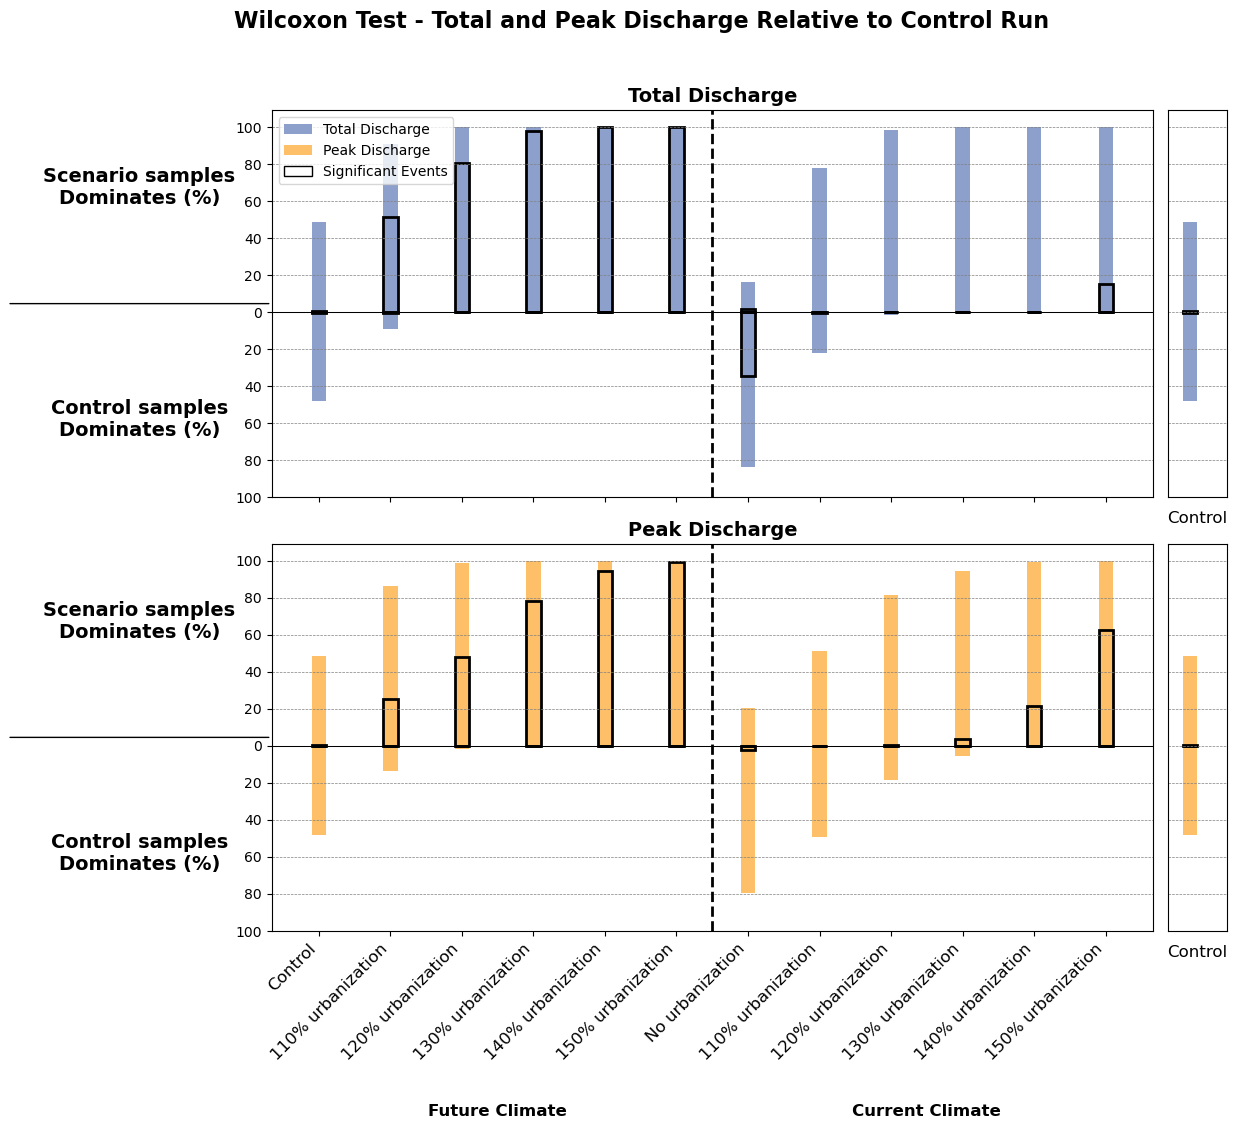

In [13]:
fig, ((ax_total, ax_total_control), (ax_max, ax_max_control)) = plt.subplots(
    2, 2, figsize=(12, 12), gridspec_kw={'width_ratios': [15, 1]}, sharey='row', sharex='col'
)

# Center the bars in the control subplots
control_bar_position = 0  # Center of the control subplot
control_bar_width = 0.5   # Adjust bar width for visual clarity

metric_total_label = metrics[0]
metric_max_label = metrics[1]

# Filter data for Total Discharge
historical_all_total = [all_events_direc_df['historical_count'].loc[metric_total_label] / 10000 * 100 for all_events_direc_df in all_data]
future_all_total = [all_events_direc_df['future_count'].loc[metric_total_label] / 10000 * 100 for all_events_direc_df in all_data]
historical_sig_total = [significant_events_direc_df['historical_count'].loc[metric_total_label] / 10000 * 100 for significant_events_direc_df in significant_data]
future_sig_total = [significant_events_direc_df['future_count'].loc[metric_total_label] / 10000 * 100 for significant_events_direc_df in significant_data]

# Plot Total Discharge
for idx, (hist_all, fut_all, hist_sig, fut_sig) in enumerate(zip(historical_all_total, future_all_total, historical_sig_total, future_sig_total)):
    ax_total.bar(bar_positions[idx], -hist_all, width=bar_width, color=color_total, label='Historical' if idx == 0 else "")
    ax_total.bar(bar_positions[idx], fut_all, width=bar_width, color=color_total, label='Future' if idx == 0 else "")
    ax_total.bar(bar_positions[idx], -hist_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_total.bar(bar_positions[idx], fut_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)

# Add Control bars for Total Discharge (small subplot)
if control_index is not None:
    ax_total_control.bar(control_bar_position - control_bar_width / 2, -historical_all_total[control_index], width=control_bar_width, color=color_total)
    ax_total_control.bar(control_bar_position - control_bar_width / 2, future_all_total[control_index], width=control_bar_width, color=color_total)
    ax_total_control.bar(control_bar_position - control_bar_width / 2, -historical_sig_total[control_index], width=control_bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_total_control.bar(control_bar_position - control_bar_width / 2, future_sig_total[control_index], width=control_bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_total_control.set_xlim(-1, 1)  # Center the bars in the subplot

# Plot Peak Discharge
historical_all_max = [all_events_direc_df['historical_count'].loc[metric_max_label] / 10000 * 100 for all_events_direc_df in all_data]
future_all_max = [all_events_direc_df['future_count'].loc[metric_max_label] / 10000 * 100 for all_events_direc_df in all_data]
historical_sig_max = [significant_events_direc_df['historical_count'].loc[metric_max_label] / 10000 * 100 for significant_events_direc_df in significant_data]
future_sig_max = [significant_events_direc_df['future_count'].loc[metric_max_label] / 10000 * 100 for significant_events_direc_df in significant_data]

for idx, (hist_all, fut_all, hist_sig, fut_sig) in enumerate(zip(historical_all_max, future_all_max, historical_sig_max, future_sig_max)):
    ax_max.bar(bar_positions[idx], -hist_all, width=bar_width, color=color_max, label='Historical' if idx == 0 else "")
    ax_max.bar(bar_positions[idx], fut_all, width=bar_width, color=color_max, label='Future' if idx == 0 else "")
    ax_max.bar(bar_positions[idx], -hist_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_max.bar(bar_positions[idx], fut_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)

# Add Control bars for Peak Discharge (small subplot)
if control_index is not None:
    ax_max_control.bar(control_bar_position - control_bar_width / 2, -historical_all_max[control_index], width=control_bar_width, color=color_max)
    ax_max_control.bar(control_bar_position - control_bar_width / 2, future_all_max[control_index], width=control_bar_width, color=color_max)
    ax_max_control.bar(control_bar_position - control_bar_width / 2, -historical_sig_max[control_index], width=control_bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_max_control.bar(control_bar_position - control_bar_width / 2, future_sig_max[control_index], width=control_bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_max_control.set_xlim(-1, 1)  # Center the bars in the subplot

# Add vertical line to both main plots
if vertical_line_position is not None:
    ax_total.axvline(x=vertical_line_position, color='black', linestyle='--', linewidth=2)
    ax_max.axvline(x=vertical_line_position, color='black', linestyle='--', linewidth=2)

# Add text below the lower main plot
if vertical_line_position is not None:
    ax_max.text(vertical_line_position - 3, -200, 'Future Climate', fontsize=12, weight='bold', ha='center')
    ax_max.text(vertical_line_position + 3, -200, 'Current Climate', fontsize=12, weight='bold', ha='center')

# Format Y-axes and subplots
for ax in [ax_total, ax_max]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{abs(tick)}" for tick in y_ticks])  # Positive values for both sides
    ax.grid(which='both', axis='y', linewidth=0.5, color='gray', linestyle='--')
    ax.text(-0.15, 0.8, 'Scenario samples\nDominates (%)', transform=ax.transAxes, fontsize=14, weight='bold', ha='center', va='center')
    ax.text(-0.15, 0.2, 'Control samples\nDominates (%)', transform=ax.transAxes, fontsize=14, weight='bold', ha='center', va='center')

# Ensure X-axis labels are shown for main plots
ax_total.set_xticks(bar_positions)
ax_total.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)

ax_max.set_xticks(bar_positions)
ax_max.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)

# Add grid to control subplots
for ax_control in [ax_total_control, ax_max_control]:
    ax_control.grid(which='both', axis='y', linewidth=0.5, color='gray', linestyle='--')
    ax_control.tick_params(axis='y', which='both', left=False, labelleft=False)
    ax_control.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Titles for each subplot
ax_total.set_title('Total Discharge', fontsize=14, weight='bold')
ax_max.set_title('Peak Discharge', fontsize=14, weight='bold')
# ax_total.set_ylabel('Percentage (%)', fontsize=14, labelpad=20)
# ax_max.set_ylabel('Percentage (%)', fontsize=14, labelpad=20)
ax_total_control.set_xlabel('Control', fontsize=12, labelpad=10)
ax_max_control.set_xlabel('Control', fontsize=12, labelpad=10)


def add_horizontal_extension(ax, x_position, y_position, end_position):
    ax.annotate(
        '', 
        xy=(end_position, y_position),  # End point (left-most position)
        xytext=(x_position, y_position),  # Start point
        arrowprops=dict(arrowstyle='-', color='black', linewidth=1),
        xycoords='axes fraction',  # Relative to axes
        textcoords='axes fraction'
    )


# Add to both main plots
add_horizontal_extension(ax_total, x_position=0, y_position=0.5, end_position=-0.3)
add_horizontal_extension(ax_max, x_position=0, y_position=0.5, end_position=-0.3)

# Add legend to Total Discharge plot
handles = [
    Patch(facecolor=color_total, label='Total Discharge'),
    Patch(facecolor=color_max, label='Peak Discharge'),
    Patch(facecolor='none', edgecolor='black', label='Significant Events')
]
ax_total.legend(handles=handles, loc='upper left', fontsize=10, bbox_to_anchor=(0, 1))

# Main title and save
fig.suptitle('Wilcoxon Test - Total and Peak Discharge Relative to Control Run', fontsize=16, weight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
combined_plot_path = os.path.join(combined_plot_dir, 'total_and_peak_discharge_vertical_with_control_and_grid.png')
plt.savefig(combined_plot_path, dpi=300)
plt.show()


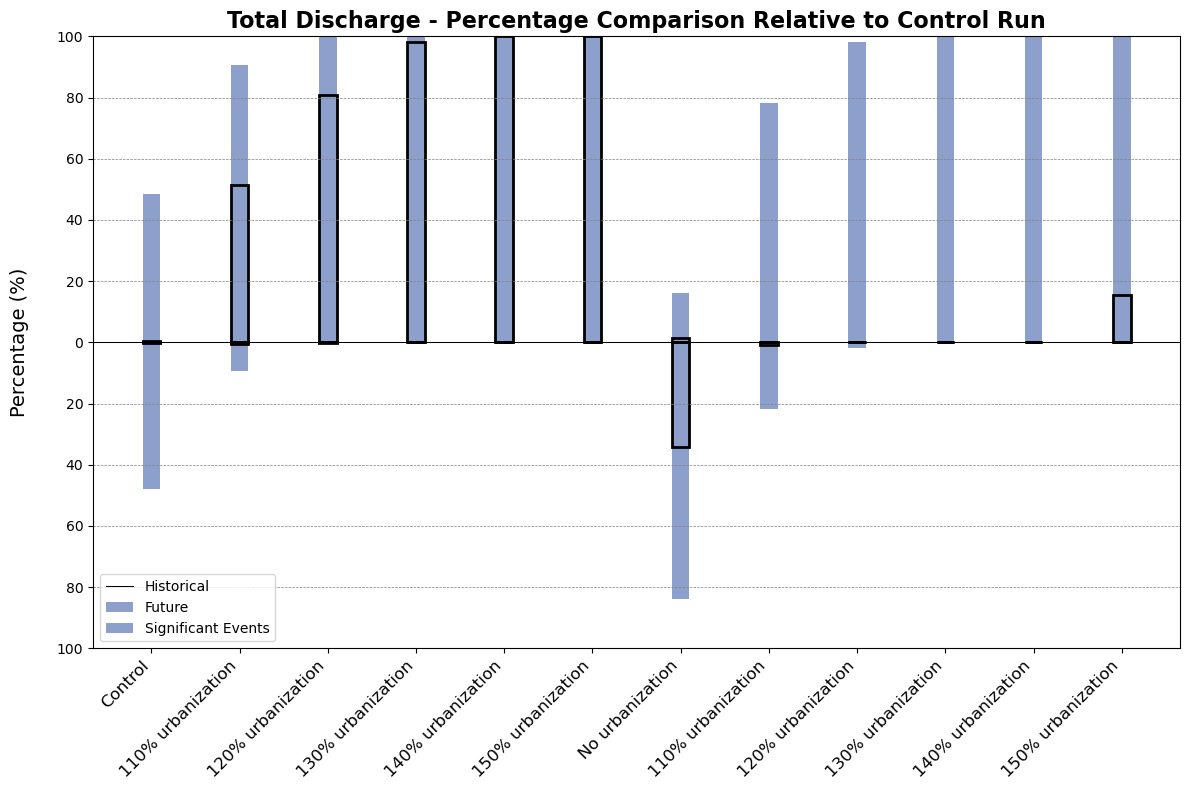

In [14]:
# Total Discharge Plot
fig, ax_total = plt.subplots(figsize=(12, 8))

# Set shared y-axis limits and ticks
shared_y_min = -100
shared_y_max = 100
y_ticks = np.arange(shared_y_min, shared_y_max + 1, 20)

# Apply y-axis limits and ticks
ax_total.set_ylim(shared_y_min, shared_y_max)
ax_total.set_yticks(y_ticks)

# Update y-ticks to display absolute values
y_tick_labels = [f"{abs(tick)}" for tick in y_ticks]
ax_total.set_yticklabels(y_tick_labels)

# Add gridlines
ax_total.grid(which='both', axis='y', linewidth=0.5, color='gray', linestyle='--')

# Plot Total Discharge
for idx, (all_events, sig_events) in enumerate(zip(all_data, significant_data)):
    hist_all = all_events['historical_count'].iloc[0] / 10000 * 100
    fut_all = all_events['future_count'].iloc[0] / 10000 * 100
    hist_sig = sig_events['historical_count'].iloc[0] / 10000 * 100
    fut_sig = sig_events['future_count'].iloc[0] / 10000 * 100

    ax_total.bar(bar_positions[idx], -hist_all, width=bar_width, color=color_total, label='Historical' if idx == 0 else "")
    ax_total.bar(bar_positions[idx], fut_all, width=bar_width, color=color_total, label='Future' if idx == 0 else "")
    ax_total.bar(bar_positions[idx], -hist_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_total.bar(bar_positions[idx], fut_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)

# Add formatting
ax_total.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_total.set_xticks(bar_positions)
ax_total.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)
ax_total.set_ylabel('Percentage (%)', fontsize=14, labelpad=20)
ax_total.legend(['Historical', 'Future', 'Significant Events'], fontsize=10)
ax_total.set_title('Total Discharge - Percentage Comparison Relative to Control Run', fontsize=16, weight='bold')

# Save and show
plt.tight_layout()
total_discharge_path = os.path.join(combined_plot_dir, 'total_discharge_percentage_plot.png')
plt.savefig(total_discharge_path, dpi=300)
plt.show()


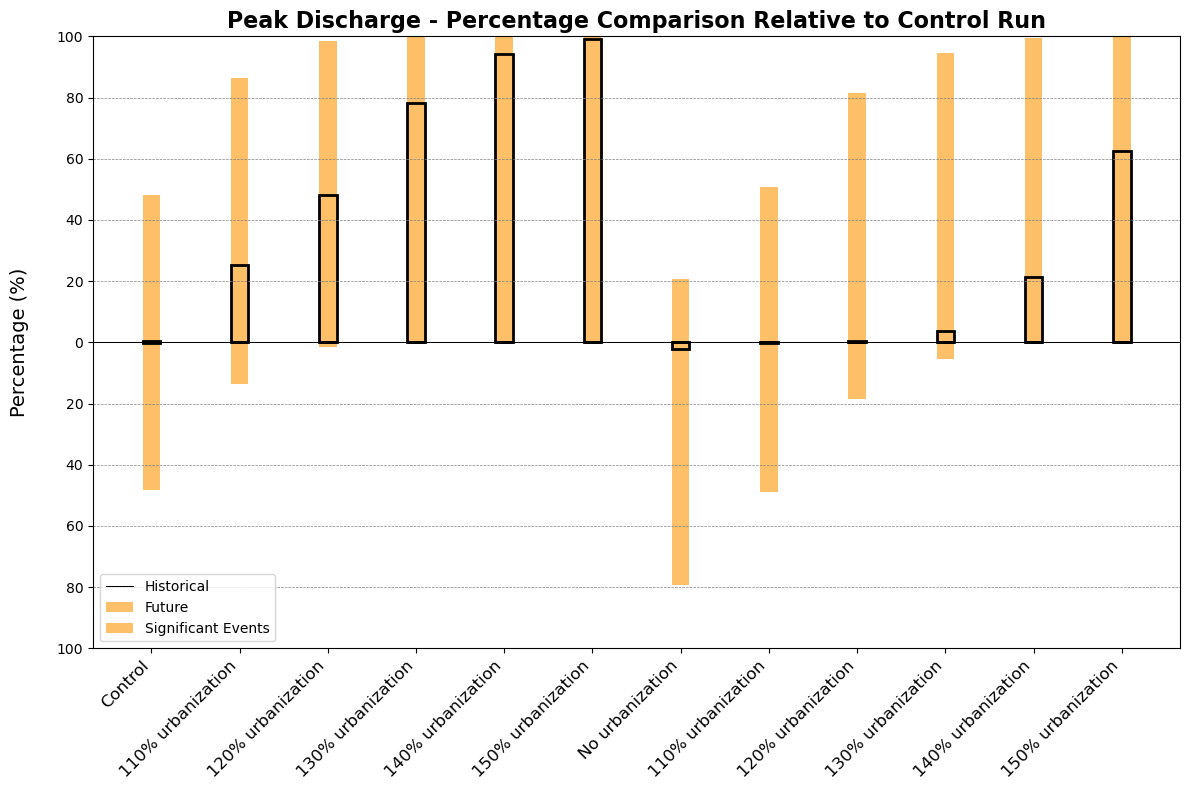

In [15]:
# Peak Discharge Plot
fig, ax_peak = plt.subplots(figsize=(12, 8))

# Set shared y-axis limits and ticks
ax_peak.set_ylim(shared_y_min, shared_y_max)
ax_peak.set_yticks(y_ticks)

# Update y-ticks to display absolute values
ax_peak.set_yticklabels(y_tick_labels)

# Add gridlines
ax_peak.grid(which='both', axis='y', linewidth=0.5, color='gray', linestyle='--')

# Plot Peak Discharge
for idx, (all_events, sig_events) in enumerate(zip(all_data, significant_data)):
    hist_all = all_events['historical_count'].iloc[1] / 10000 * 100
    fut_all = all_events['future_count'].iloc[1] / 10000 * 100
    hist_sig = sig_events['historical_count'].iloc[1] / 10000 * 100
    fut_sig = sig_events['future_count'].iloc[1] / 10000 * 100

    ax_peak.bar(bar_positions[idx], -hist_all, width=bar_width, color=color_max, label='Historical' if idx == 0 else "")
    ax_peak.bar(bar_positions[idx], fut_all, width=bar_width, color=color_max, label='Future' if idx == 0 else "")
    ax_peak.bar(bar_positions[idx], -hist_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)
    ax_peak.bar(bar_positions[idx], fut_sig, width=bar_width, edgecolor='black', linewidth=2, fill=False)

# Add formatting
ax_peak.axhline(y=0, color='black', linestyle='-', linewidth=0.75)
ax_peak.set_xticks(bar_positions)
ax_peak.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)
ax_peak.set_ylabel('Percentage (%)', fontsize=14, labelpad=20)
ax_peak.legend(['Historical', 'Future', 'Significant Events'], fontsize=10)
ax_peak.set_title('Peak Discharge - Percentage Comparison Relative to Control Run', fontsize=16, weight='bold')

# Save and show
plt.tight_layout()
peak_discharge_path = os.path.join(combined_plot_dir, 'peak_discharge_percentage_plot.png')
plt.savefig(peak_discharge_path, dpi=300)
plt.show()
